# Intent–Behavior Deviation in Smart Contracts
## Notebook 0: Dataset Upload + EDA + Visualization
**Dataset:** ml_dataset_verified_full.csv · 3,324 contracts · 398 features  
**Label column:** `target` (0 = safe, 1 = rugpull)  
**Embeddings:** `emb_000` … `emb_383` (384-d MiniLM)  
**Behavior:** `owner_withdraw`, `slither_*` … (14 Slither/regex flags)

## STEP 0 — Upload Your Dataset to Kaggle 

In [1]:
import io, requests

# ─────────────────────────────────────────────────────────────────────────────
# Load dataset directly from GitHub (raw CSV)
# ─────────────────────────────────────────────────────────────────────────────
GITHUB_RAW_URL = (
    'https://raw.githubusercontent.com/AbrarBb/Intent-Behavior-Deviation-Dataset'
    '/main/ml_dataset_verified_full.csv'
)

print('Downloading dataset from GitHub...')
response = requests.get(GITHUB_RAW_URL)
response.raise_for_status()
CSV_PATH = io.StringIO(response.text)
print('✅ Dataset loaded successfully from GitHub')

✅ Dataset loaded successfully from GitHub


In [2]:
!pip install -q umap-learn

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns, json, warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif
import umap

plt.rcParams['figure.dpi'] = 120
COLORS = ['#2ec7cc','#db70c0']   # blue=safe  pink=rugpull
SEED = 42;  np.random.seed(SEED)
print('Imports OK')

2026-04-18 18:13:35.739399: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776536016.203625      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776536016.317358      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776536017.382255      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776536017.382304      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776536017.382307      23 computation_placer.cc:177] computation placer alr

Imports OK


In [4]:
df = pd.read_csv(CSV_PATH)

# ── Exact column names from the real dataset ──────────────────────────────────
EMB_COLS    = [c for c in df.columns if c.startswith('emb_')]  # emb_000…emb_383
BEHAV_COLS  = ['owner_withdraw','emergency_withdraw','unrestricted_mint',
               'regex_owner_withdraw','regex_emergency_withdraw','regex_unrestricted_mint',
               'slither_ok','slither_high_count','slither_arbitrary_send',
               'slither_suicidal','slither_unchecked_lowlevel',
               'slither_controlled_delegatecall','slither_delegatecall_loop',
               'slither_ownerish_any']
HYBRID_COLS = EMB_COLS + BEHAV_COLS
LABEL_COL   = 'target'   # 0=safe  1=rugpull
BINARY_BEHAV = [c for c in BEHAV_COLS if df[c].isin([0,1]).all()]

print(f'Shape         : {df.shape}')
print(f'Embedding cols: {len(EMB_COLS)}  ({EMB_COLS[0]}…{EMB_COLS[-1]})')
print(f'Behavior cols : {len(BEHAV_COLS)}')
print(f'Hybrid total  : {len(HYBRID_COLS)}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f"\nClass distribution (target):")
print(df[LABEL_COL].value_counts().rename({0:'Safe',1:'Rugpull'}))

Shape         : (3324, 402)
Embedding cols: 384  (emb_000…emb_383)
Behavior cols : 14
Hybrid total  : 398
Missing values: 0

Class distribution (target):
target
Rugpull    2302
Safe       1022
Name: count, dtype: int64


---
## 1. Class Distribution

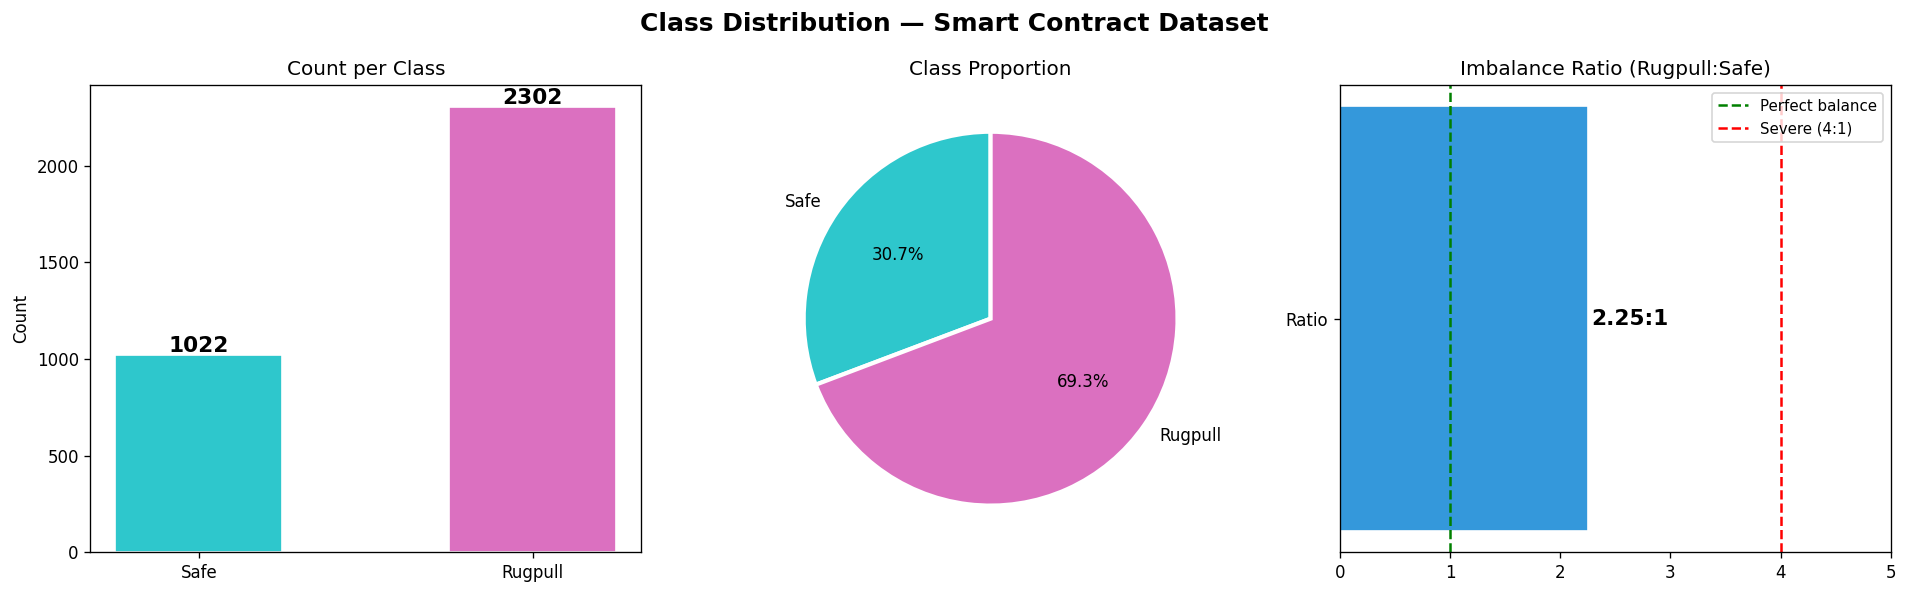

Ratio = 2.25:1 → MILD imbalance — full dataset training is valid


In [5]:
counts = df[LABEL_COL].value_counts().sort_index()
ratio  = counts[1] / counts[0]
names  = ['Safe','Rugpull']

fig, axes = plt.subplots(1,3, figsize=(16,5))
fig.suptitle('Class Distribution — Smart Contract Dataset', fontsize=15, fontweight='bold')

bars = axes[0].bar(names, counts.values, color=COLORS, edgecolor='white', width=0.5)
for bar,v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Count per Class'); axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=names, colors=COLORS, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white',linewidth=2.5))
axes[1].set_title('Class Proportion')

axes[2].barh(['Ratio'], [ratio], color='#3498db', edgecolor='white')
axes[2].axvline(1, color='green', linestyle='--', label='Perfect balance')
axes[2].axvline(4, color='red',   linestyle='--', label='Severe (4:1)')
axes[2].text(ratio+0.03, 0, f'{ratio:.2f}:1', va='center', fontsize=13, fontweight='bold')
axes[2].set_xlim(0,5); axes[2].legend(fontsize=9)
axes[2].set_title('Imbalance Ratio (Rugpull:Safe)')

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f'Ratio = {ratio:.2f}:1 → MILD imbalance — full dataset training is valid')

---
## 2. Behavior Feature Analysis

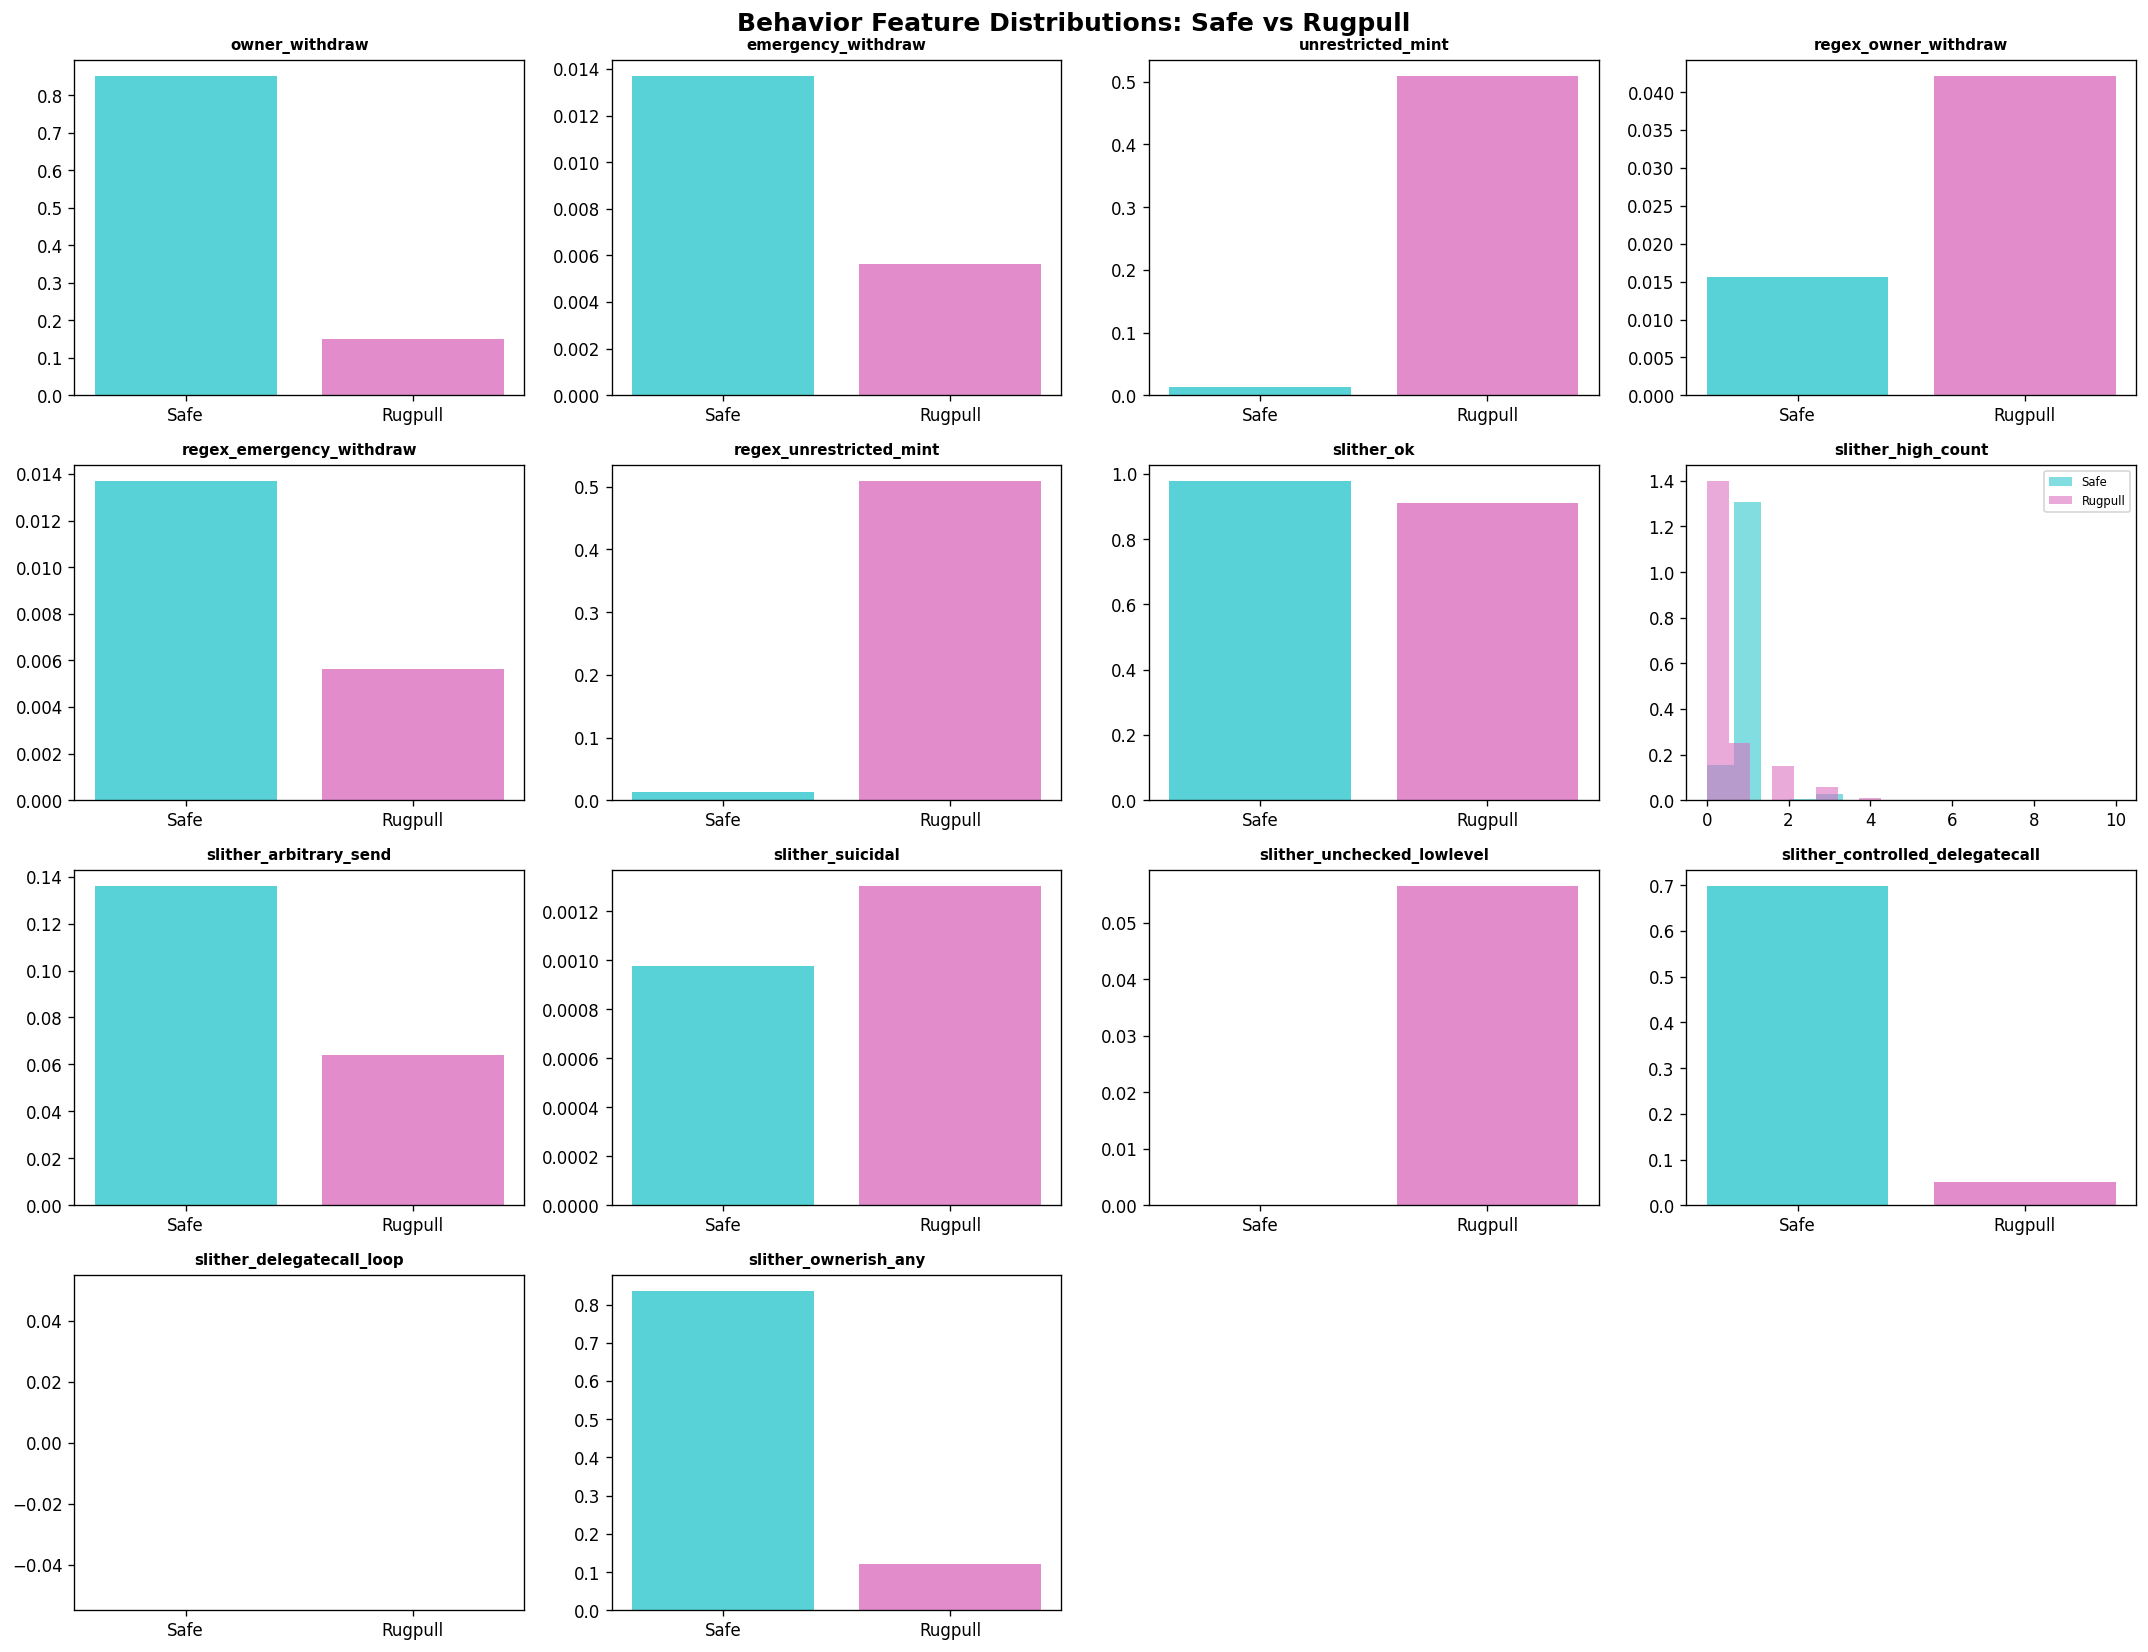

In [6]:
# 2A — per-feature distribution by class
ncols=4; nrows=(len(BEHAV_COLS)+ncols-1)//ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows*3.5))
fig.suptitle('Behavior Feature Distributions: Safe vs Rugpull', fontsize=15, fontweight='bold')
axes = axes.flatten()
for i,col in enumerate(BEHAV_COLS):
    for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
        v = df[df[LABEL_COL]==label][col]
        if col in BINARY_BEHAV:
            axes[i].bar([name],[v.mean()], color=color, alpha=0.8)
        else:
            axes[i].hist(v, bins=15, color=color, alpha=0.6, label=name, density=True)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    if col not in BINARY_BEHAV: axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('plot_02_behavior_distributions.png', bbox_inches='tight')
plt.show()

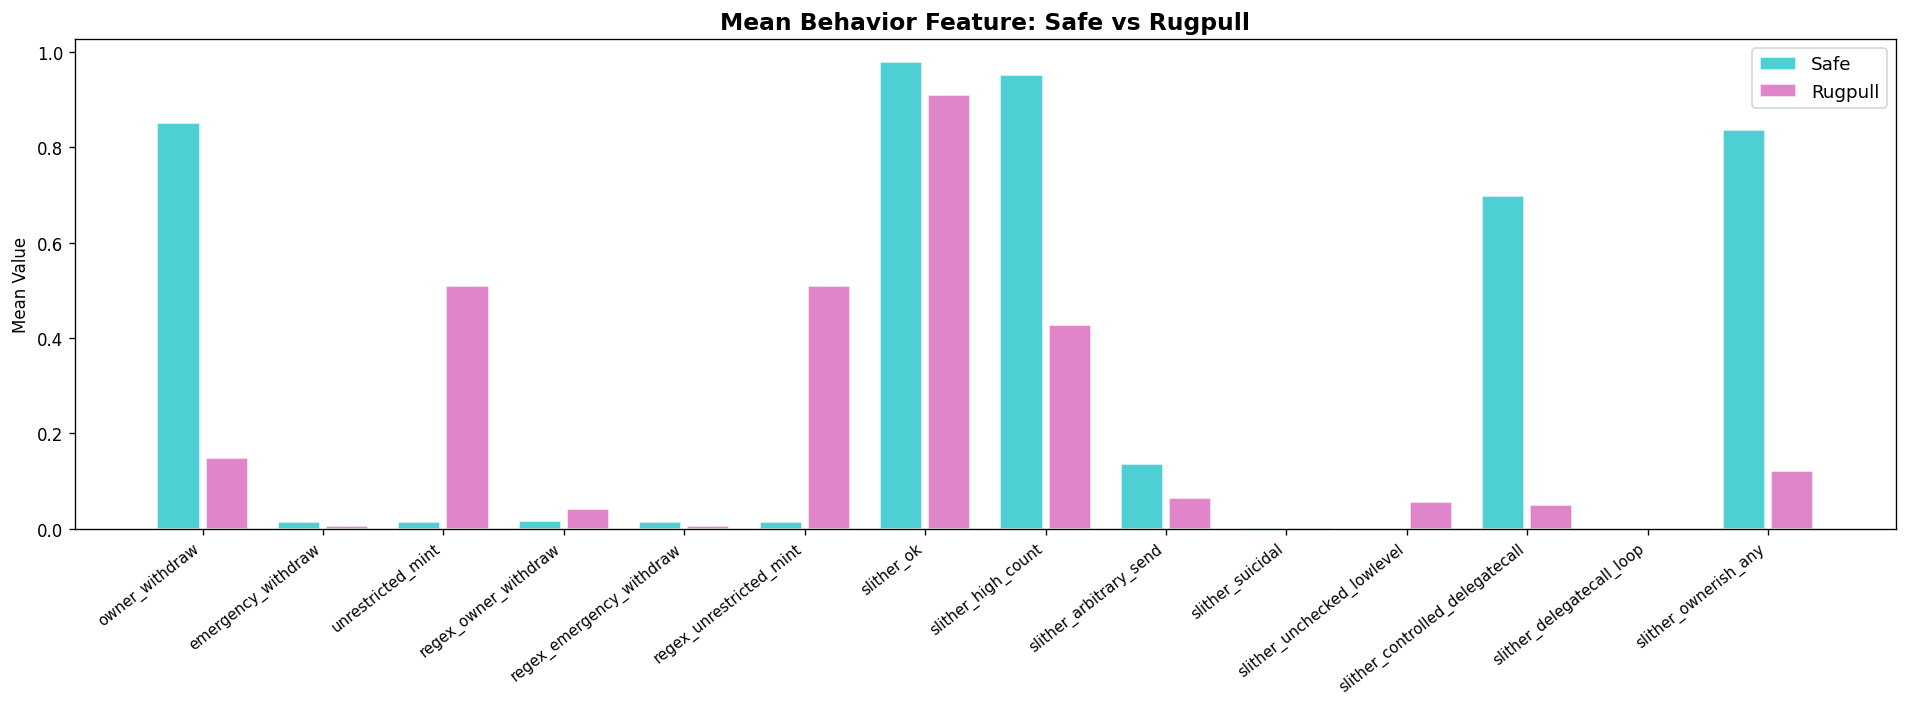

In [7]:
# 2B — mean comparison bar chart
safe_m = df[df[LABEL_COL]==0][BEHAV_COLS].mean()
rug_m  = df[df[LABEL_COL]==1][BEHAV_COLS].mean()
x = np.arange(len(BEHAV_COLS))
fig, ax = plt.subplots(figsize=(16,6))
ax.bar(x-0.2, safe_m, 0.35, label='Safe',    color=COLORS[0], alpha=0.85, edgecolor='white')
ax.bar(x+0.2, rug_m,  0.35, label='Rugpull', color=COLORS[1], alpha=0.85, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(BEHAV_COLS, rotation=38, ha='right', fontsize=9)
ax.set_title('Mean Behavior Feature: Safe vs Rugpull', fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Value'); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_03_behavior_mean.png', bbox_inches='tight')
plt.show()

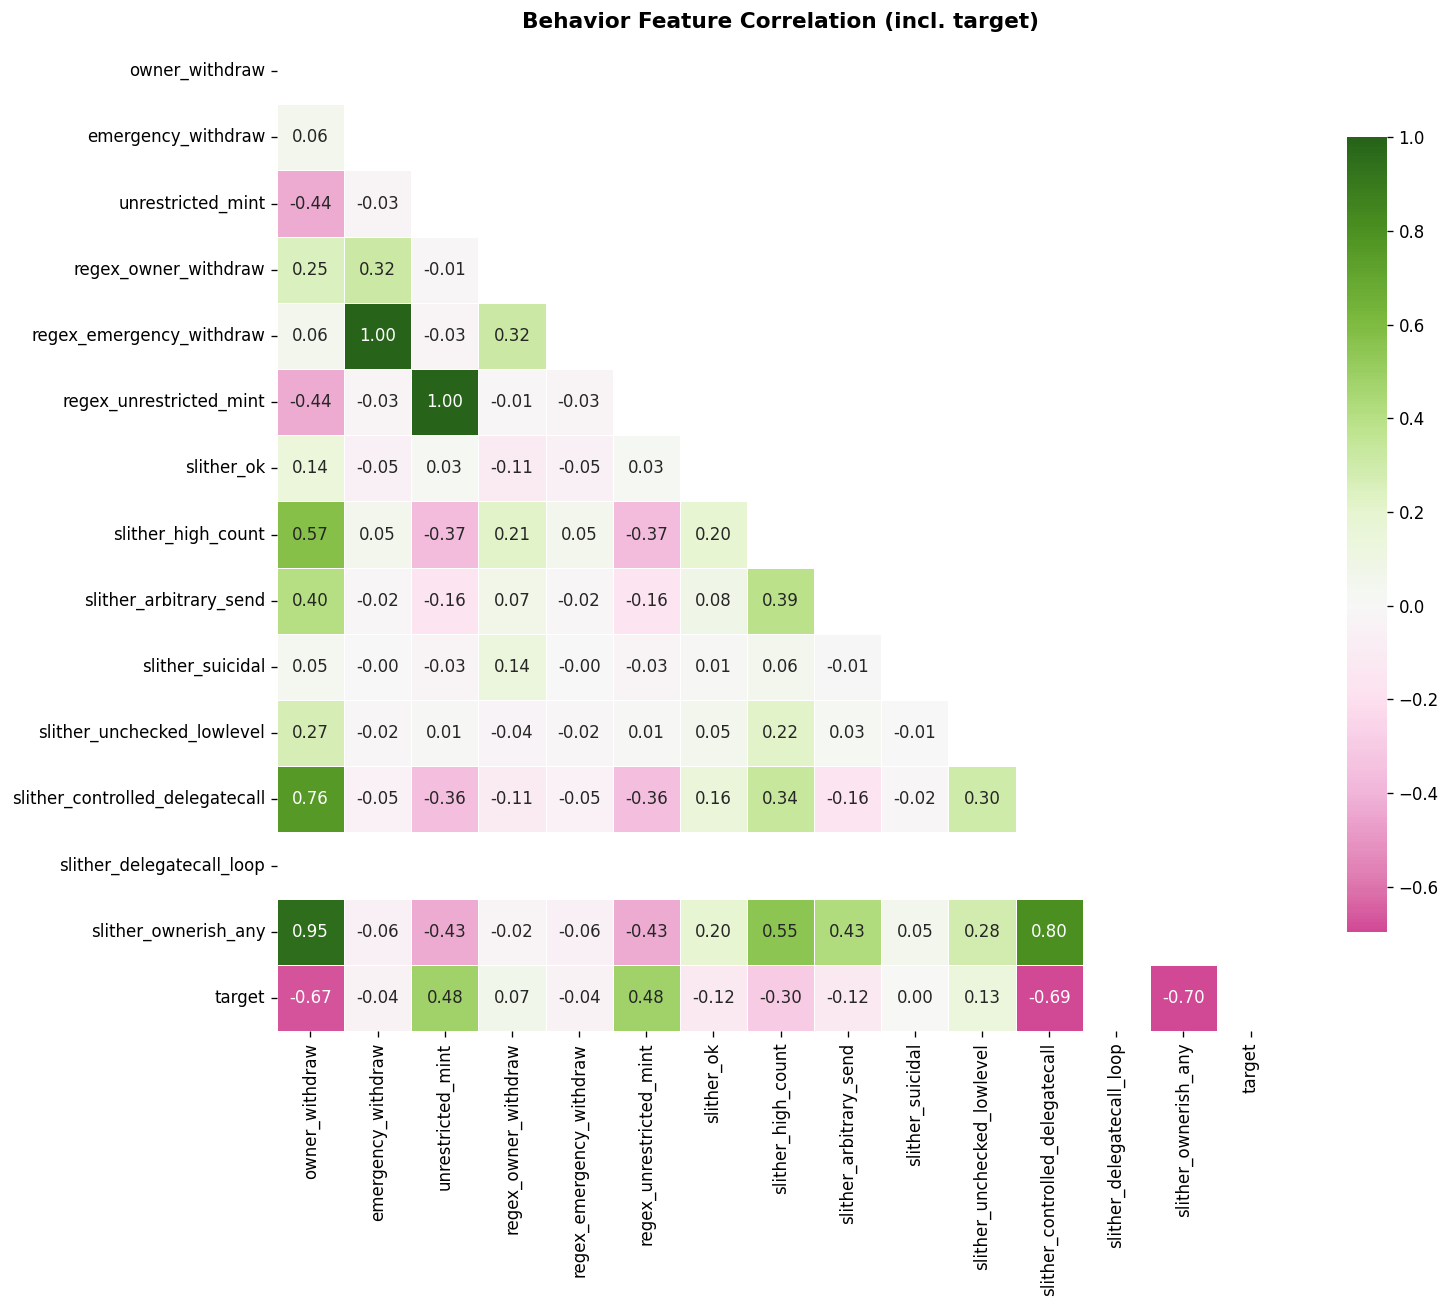

In [8]:
# 2C — correlation heatmap
corr = df[BEHAV_COLS+[LABEL_COL]].corr()
fig, ax = plt.subplots(figsize=(13,11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='PiYG',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink':0.8})
ax.set_title('Behavior Feature Correlation (incl. target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_behavior_correlation.png', bbox_inches='tight')
plt.show()

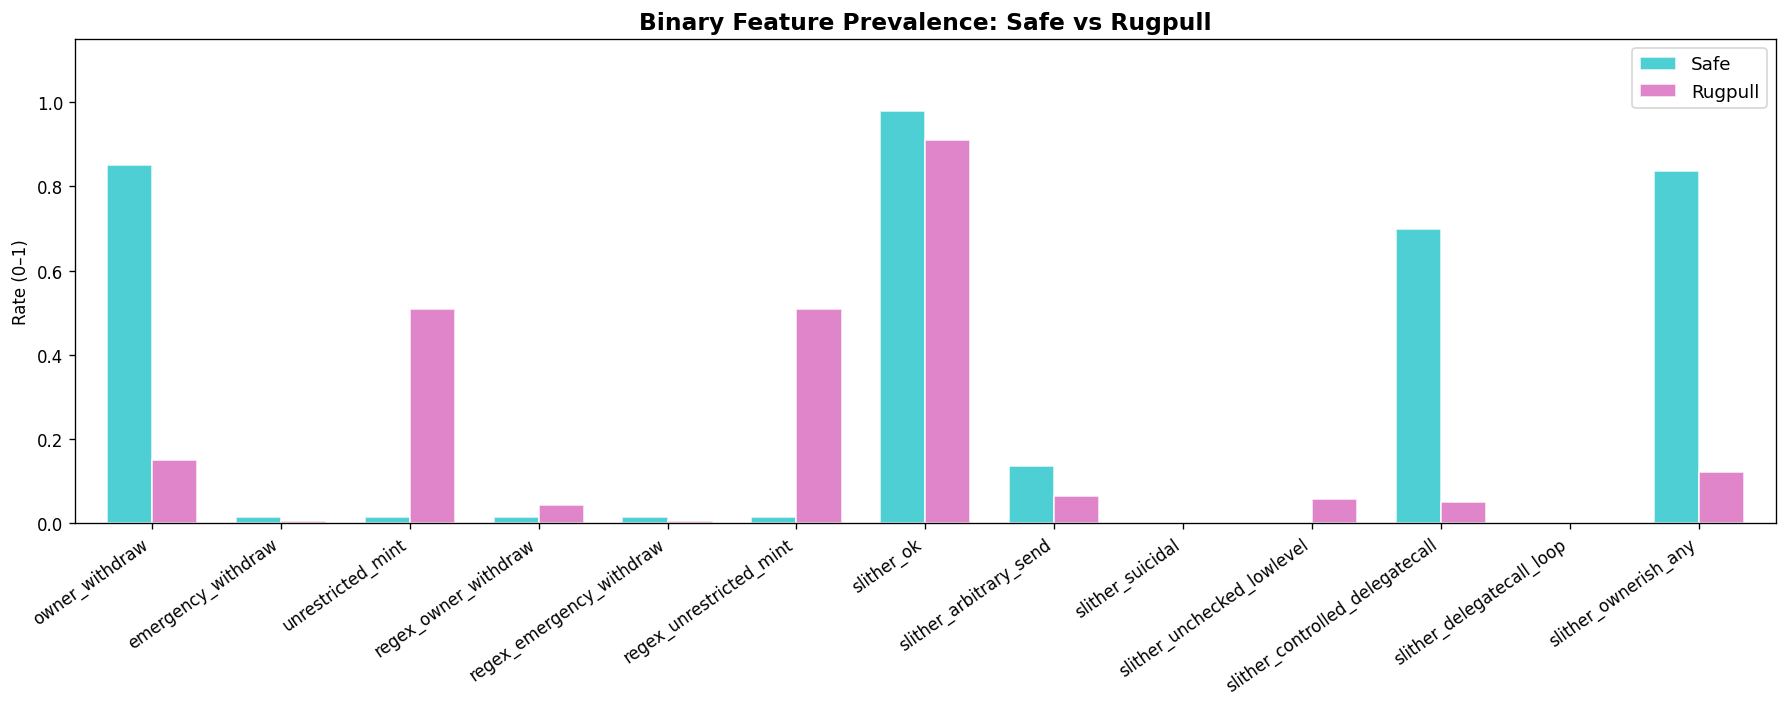

In [9]:
# 2D — binary feature prevalence rates
rates = pd.DataFrame({'Safe':   df[df[LABEL_COL]==0][BINARY_BEHAV].mean(),
                       'Rugpull':df[df[LABEL_COL]==1][BINARY_BEHAV].mean()})
fig, ax = plt.subplots(figsize=(15,6))
rates.plot(kind='bar', ax=ax, color=COLORS, alpha=0.85, edgecolor='white', width=0.7)
ax.set_title('Binary Feature Prevalence: Safe vs Rugpull', fontsize=14, fontweight='bold')
ax.set_ylabel('Rate (0–1)'); ax.set_ylim(0,1.15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(['Safe','Rugpull'], fontsize=11)
plt.tight_layout()
plt.savefig('plot_05_binary_rates.png', bbox_inches='tight')
plt.show()

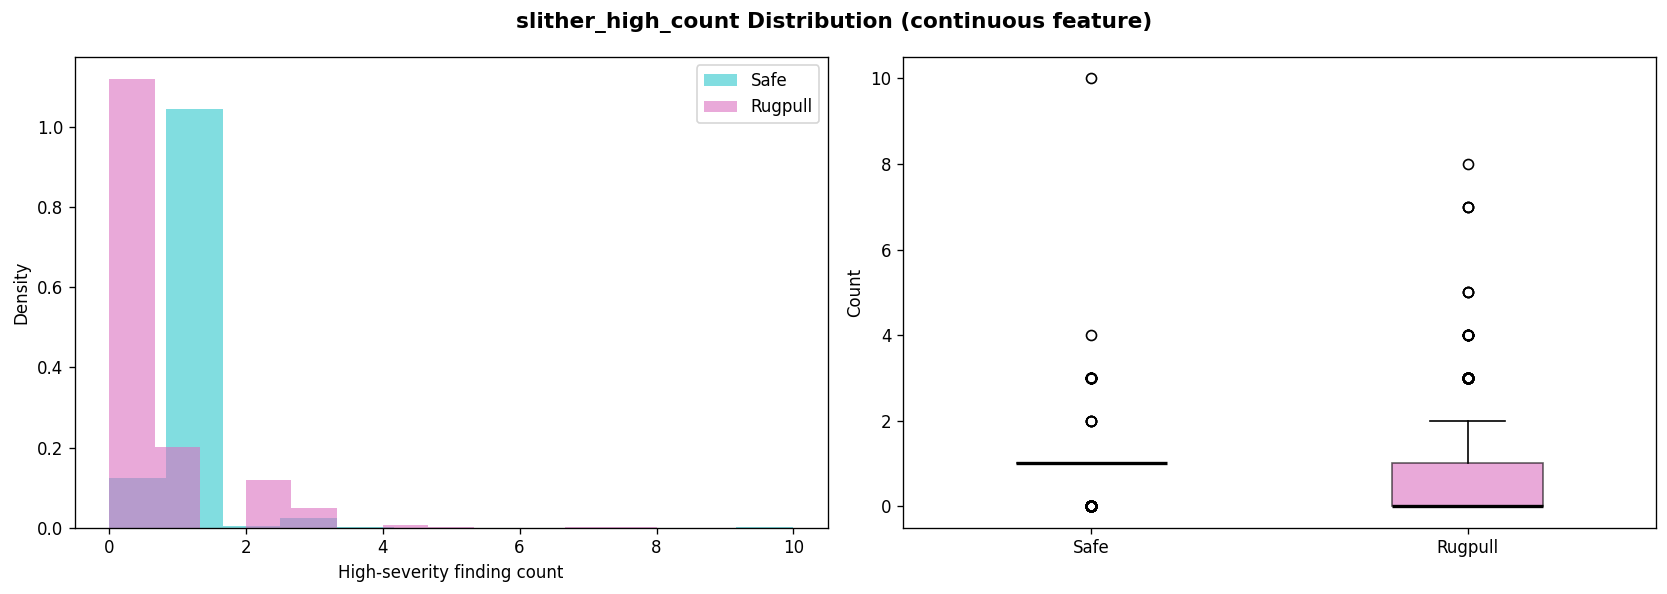

In [10]:
# 2E — slither_high_count (only continuous behavior feature)
fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('slither_high_count Distribution (continuous feature)', fontsize=13, fontweight='bold')
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    v = df[df[LABEL_COL]==label]['slither_high_count']
    axes[0].hist(v, bins=12, color=color, alpha=0.6, label=name, density=True)
    axes[1].boxplot(v, positions=[label], widths=0.4, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.6),
                    medianprops=dict(color='black',linewidth=2))
axes[0].set_xlabel('High-severity finding count'); axes[0].set_ylabel('Density'); axes[0].legend()
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['Safe','Rugpull']); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot_06_slither_high_count.png', bbox_inches='tight')
plt.show()

---
## 3. Intent Embedding Analysis

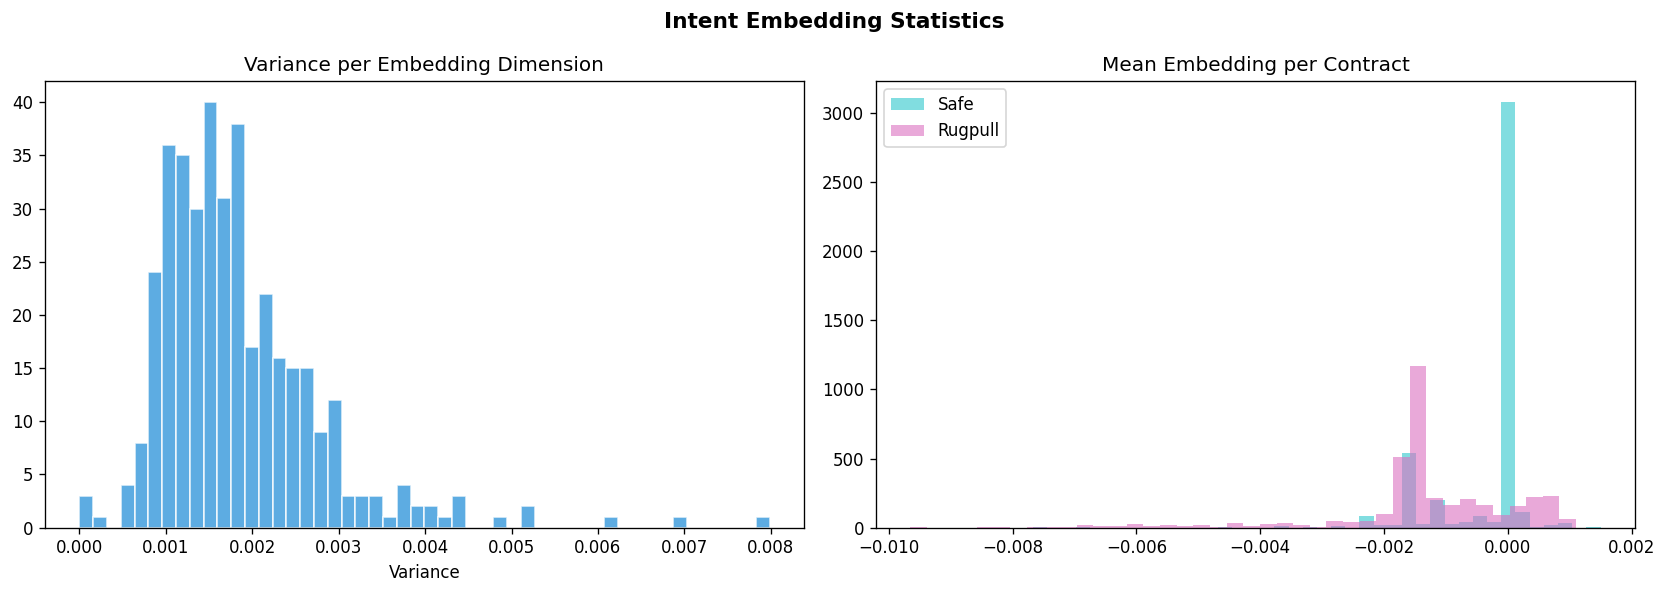

In [11]:
X_emb = df[EMB_COLS].values
y     = df[LABEL_COL].values

fig, axes = plt.subplots(1,2, figsize=(14,5))
fig.suptitle('Intent Embedding Statistics', fontsize=13, fontweight='bold')
axes[0].hist(df[EMB_COLS].var(), bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Variance per Embedding Dimension'); axes[0].set_xlabel('Variance')
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    axes[1].hist(df[EMB_COLS].mean(axis=1)[y==label], bins=40,
                 color=color, alpha=0.6, label=name, density=True)
axes[1].set_title('Mean Embedding per Contract'); axes[1].legend()
plt.tight_layout()
plt.savefig('plot_07_embedding_stats.png', bbox_inches='tight')
plt.show()

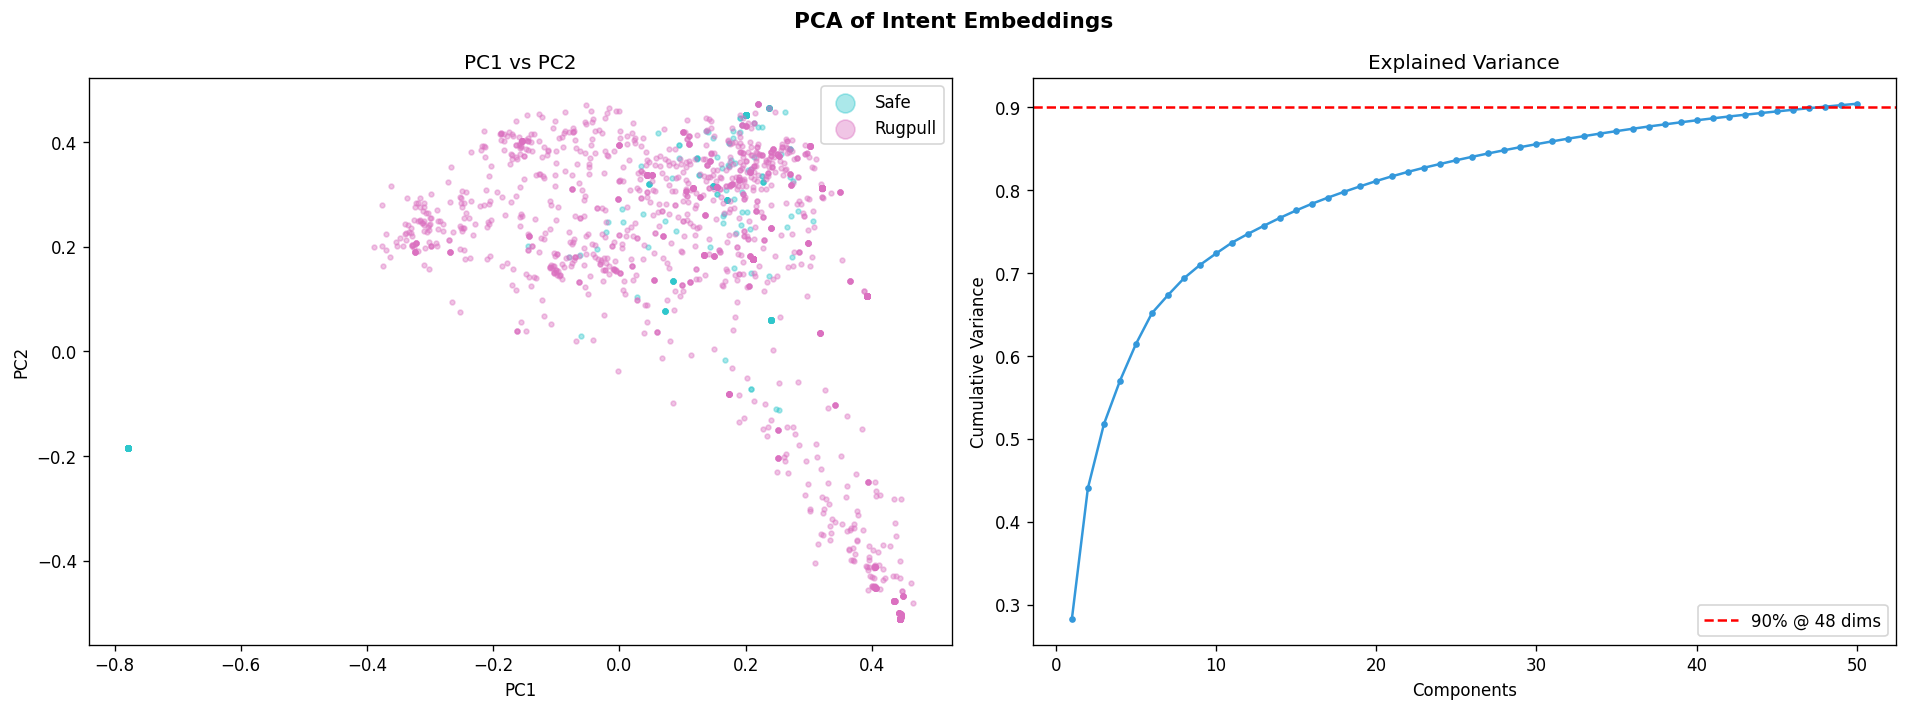

90% variance at 48 components


In [12]:
pca = PCA(n_components=50, random_state=SEED)
X_pca50 = pca.fit_transform(X_emb)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n90 = np.argmax(cum_var>=0.9)+1

fig, axes = plt.subplots(1,2, figsize=(16,6))
fig.suptitle('PCA of Intent Embeddings', fontsize=13, fontweight='bold')
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    axes[0].scatter(X_pca50[y==label,0], X_pca50[y==label,1],
                    c=color, label=name, alpha=0.4, s=8, rasterized=True)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(markerscale=4)
axes[0].set_title('PC1 vs PC2')
axes[1].plot(range(1,51), cum_var,'o-', ms=3, color='#3498db')
axes[1].axhline(0.9, color='red', linestyle='--', label=f'90% @ {n90} dims')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative Variance')
axes[1].legend(); axes[1].set_title('Explained Variance')
plt.tight_layout()
plt.savefig('plot_08_pca.png', bbox_inches='tight')
plt.show()
print(f'90% variance at {n90} components')

Running t-SNE (1–2 min)...


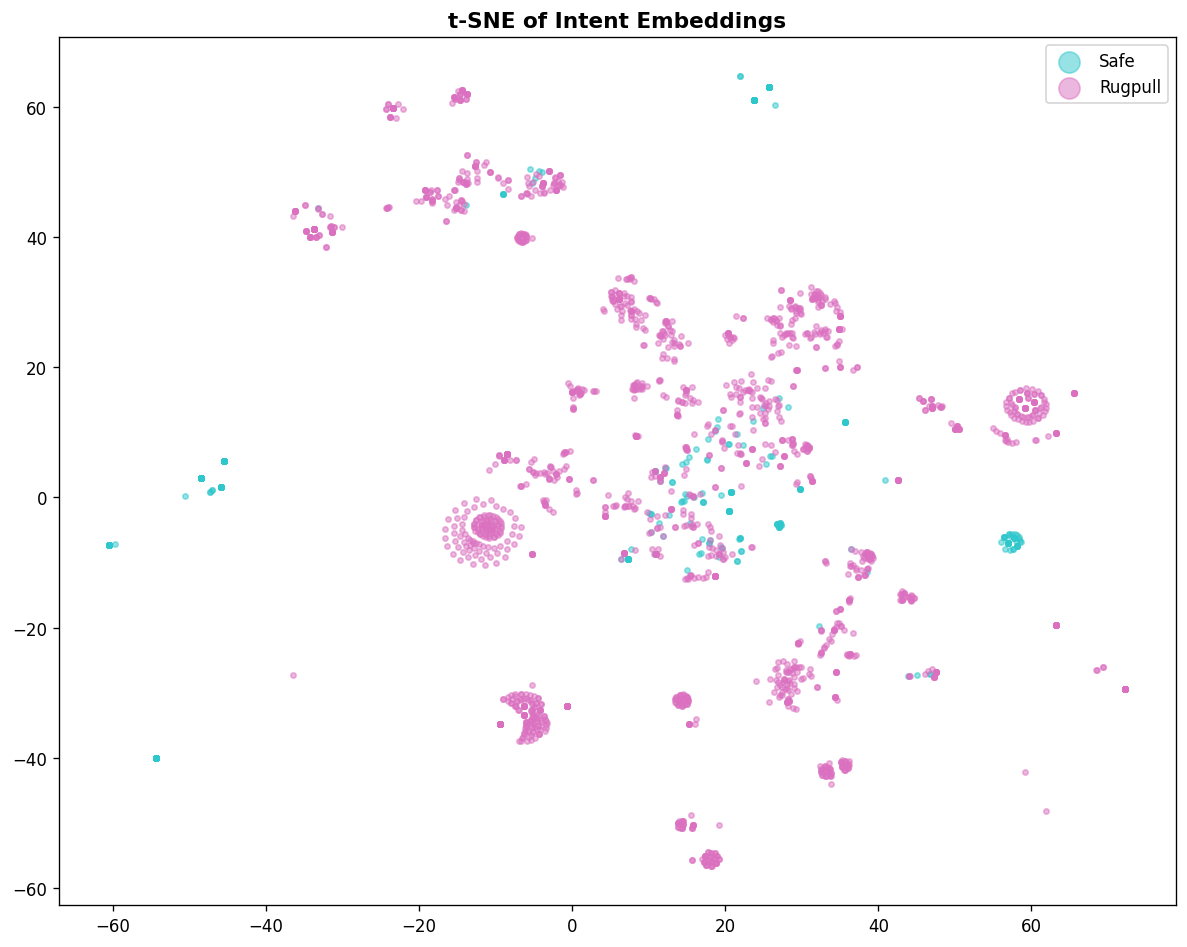

In [13]:
print('Running t-SNE (1–2 min)...')
X_pca30 = PCA(n_components=30, random_state=SEED).fit_transform(X_emb)
X_tsne  = TSNE(n_components=2, perplexity=40, n_iter=1000, random_state=SEED).fit_transform(X_pca30)
fig, ax = plt.subplots(figsize=(10,8))
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    ax.scatter(X_tsne[y==label,0], X_tsne[y==label,1],
               c=color, label=name, alpha=0.5, s=10, rasterized=True)
ax.set_title('t-SNE of Intent Embeddings', fontsize=13, fontweight='bold')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('plot_09_tsne.png', bbox_inches='tight', dpi=150)
plt.show()

Running UMAP...


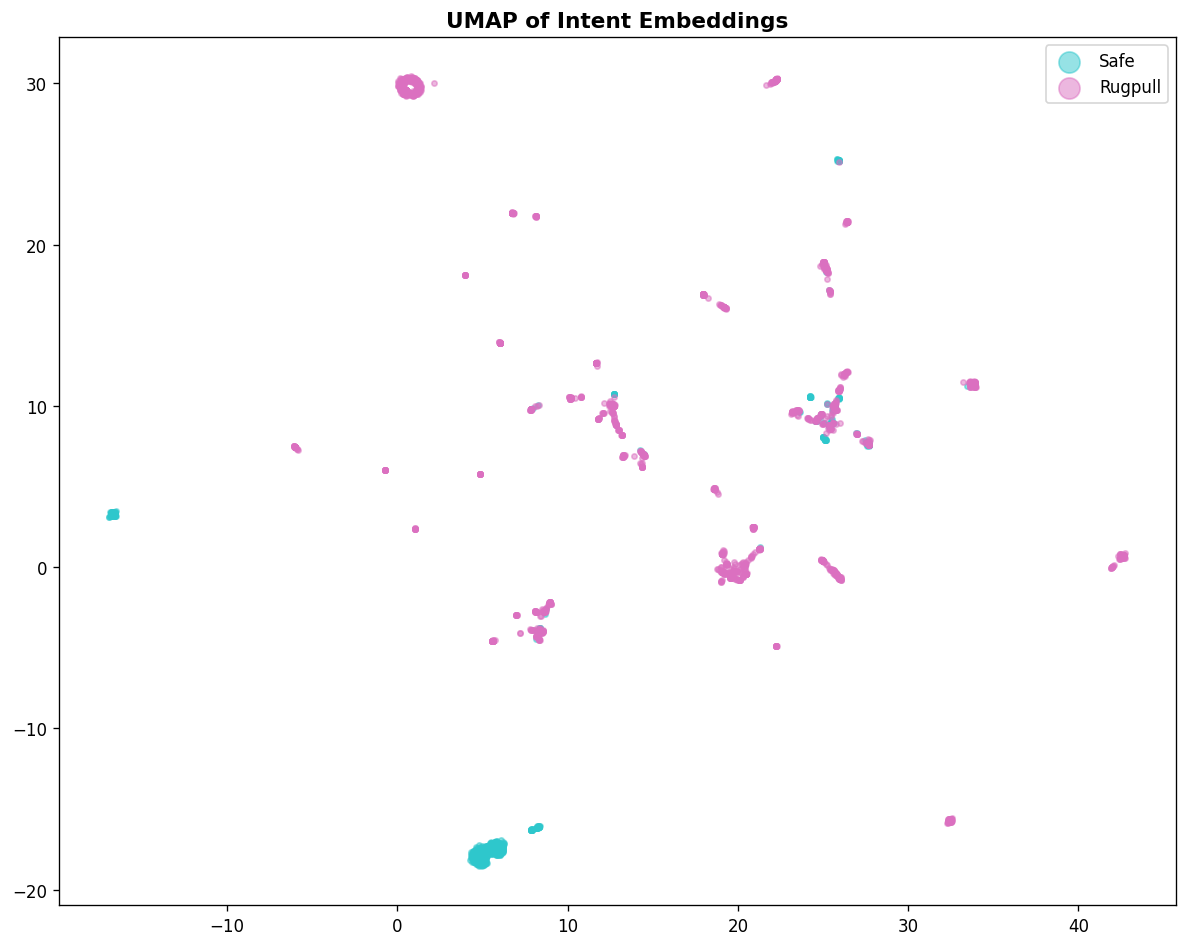

In [14]:
print('Running UMAP...')
X_umap = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=SEED).fit_transform(X_emb)
fig, ax = plt.subplots(figsize=(10,8))
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    ax.scatter(X_umap[y==label,0], X_umap[y==label,1],
               c=color, label=name, alpha=0.5, s=10, rasterized=True)
ax.set_title('UMAP of Intent Embeddings', fontsize=13, fontweight='bold')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('plot_10_umap.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Mutual Information

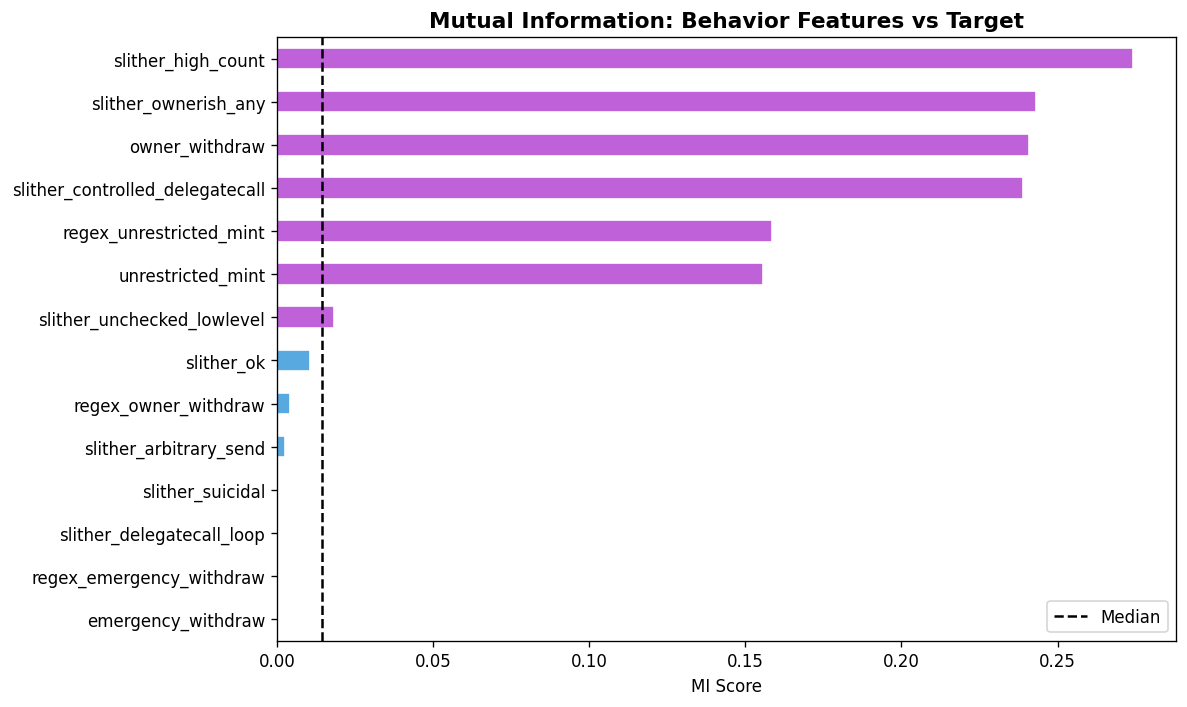

In [15]:
mi_b = mutual_info_classif(df[BEHAV_COLS].values, y, random_state=SEED)
mi_b_s = pd.Series(mi_b, index=BEHAV_COLS).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
mi_b_s.plot(kind='barh', ax=ax,
             color=['#bf62d9' if v>mi_b_s.median() else '#58a9e0' for v in mi_b_s],
             edgecolor='white')
ax.axvline(mi_b_s.median(), color='black', linestyle='--', label='Median')
ax.set_title('Mutual Information: Behavior Features vs Target', fontsize=13, fontweight='bold')
ax.set_xlabel('MI Score'); ax.legend()
plt.tight_layout()
plt.savefig('plot_11_mi_behavior.png', bbox_inches='tight')
plt.show()

Computing MI for 384 embedding dims (~30s)...


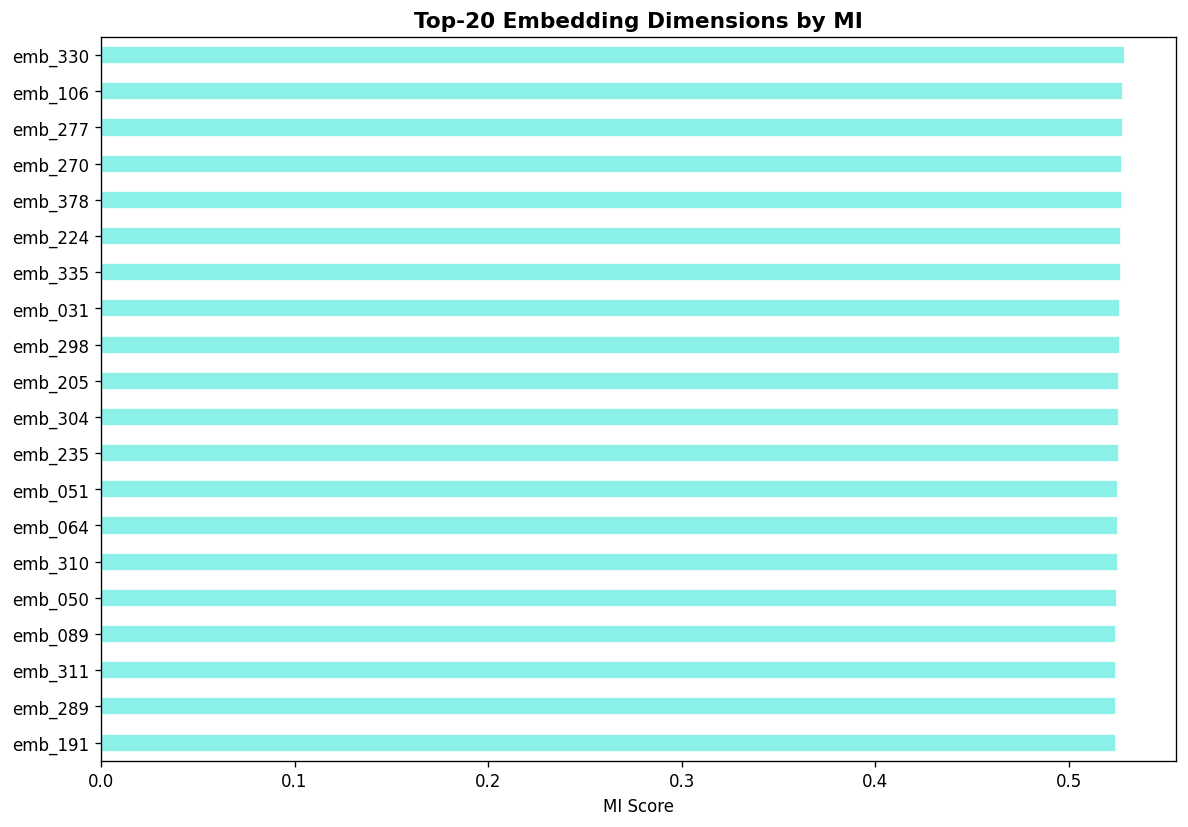

In [16]:
print('Computing MI for 384 embedding dims (~30s)...')
mi_emb = mutual_info_classif(X_emb, y, random_state=SEED)
top20  = pd.Series(mi_emb, index=EMB_COLS).nlargest(20).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10,7))
top20.plot(kind='barh', ax=ax, color='#8bf0e7', edgecolor='white')
ax.set_title('Top-20 Embedding Dimensions by MI', fontsize=13, fontweight='bold')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.savefig('plot_12_top_emb_mi.png', bbox_inches='tight')
plt.show()

---
## 5. Hybrid Space + Balanced Subset

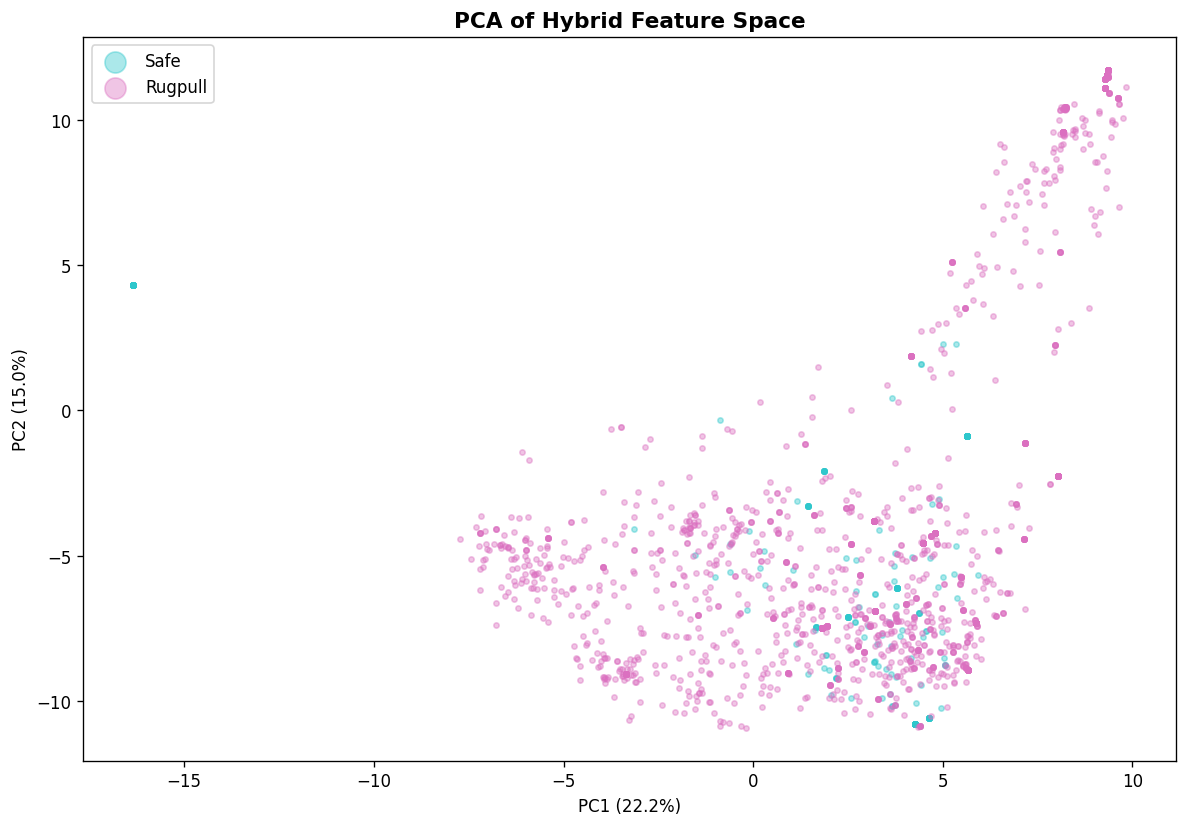

In [17]:
X_scaled = StandardScaler().fit_transform(df[HYBRID_COLS].values)
pca_h = PCA(n_components=2, random_state=SEED)
X_pca_h = pca_h.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(10,7))
for label,color,name in [(0,COLORS[0],'Safe'),(1,COLORS[1],'Rugpull')]:
    ax.scatter(X_pca_h[y==label,0], X_pca_h[y==label,1],
               c=color, label=name, alpha=0.4, s=10, rasterized=True)
ax.set_title('PCA of Hybrid Feature Space', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_h.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_h.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=4)
plt.tight_layout()
plt.savefig('plot_13_hybrid_pca.png', bbox_inches='tight')
plt.show()

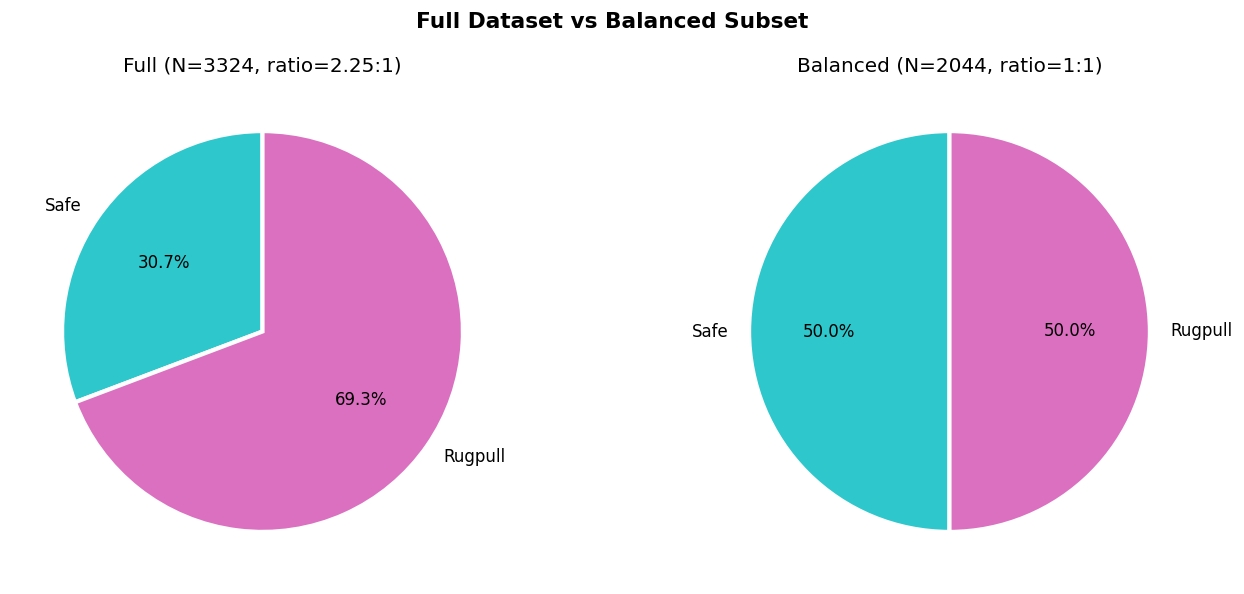

In [18]:
min_count = counts.min()
df_bal = pd.concat([
    df[df[LABEL_COL]==0].sample(min_count, random_state=SEED),
    df[df[LABEL_COL]==1].sample(min_count, random_state=SEED)
]).reset_index(drop=True)

fig, axes = plt.subplots(1,2, figsize=(12,5))
fig.suptitle('Full Dataset vs Balanced Subset', fontsize=13, fontweight='bold')
for ax,data,title in [
    (axes[0],df,         f'Full (N={len(df)}, ratio={ratio:.2f}:1)'),
    (axes[1],df_bal,     f'Balanced (N={len(df_bal)}, ratio=1:1)')
]:
    c=data[LABEL_COL].value_counts().sort_index()
    ax.pie(c.values, labels=['Safe','Rugpull'], colors=COLORS,
           autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white',linewidth=2.5))
    ax.set_title(title)
plt.tight_layout()
plt.savefig('plot_14_full_vs_balanced.png', bbox_inches='tight')
plt.show()

In [19]:
df.to_csv('dataset_full.csv', index=False)
df_bal.to_csv('dataset_balanced.csv', index=False)
with open('col_info.json','w') as f:
    json.dump({'emb_cols':EMB_COLS,'behav_cols':BEHAV_COLS,
               'hybrid_cols':HYBRID_COLS,'label_col':LABEL_COL}, f)
print('Saved: dataset_full.csv | dataset_balanced.csv | col_info.json')
print('Plots saved: 14')
print('=== EDA COMPLETE ===')

Saved: dataset_full.csv | dataset_balanced.csv | col_info.json
Plots saved: 14
=== EDA COMPLETE ===
